# <center>Support Vector Machine (SVM)

## Table of Algorithms
### Linear SVM
1. Hard-margin SVM (SGD)
2. Soft-margin SVM (GD) 
3. Soft-margin SVM (SGD)
4. Soft-margin SVM (Mini-batch GD)
### Kernel SVM
5. Kernel SVM (RBF)

---

Importing Libraries

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from hard_margin_sgd import hinge_loss
from soft_margin_gd import hinge_loss_C

Importing data

In [23]:
import os
os.path.abspath(os.path.join(os.path.dirname('02_logistic_regression'), '..'))

bezdekIris = '../data/iris/bezdekIris.data'
df = pd.read_csv(bezdekIris)

---

Checking data

In [24]:
df

,5.1,3.5,1.4,0.2,Iris-setosa
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa
...,...,...,...,...,...
144,6.7,3.0,5.2,2.3,Iris-virginica
145,6.3,2.5,5.0,1.9,Iris-virginica
146,6.5,3.0,5.2,2.0,Iris-virginica
147,6.2,3.4,5.4,2.3,Iris-virginica


In [25]:
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']

df

,sepal_length,sepal_width,petal_length,petal_width,class
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa
...,...,...,...,...,...
144,6.7,3.0,5.2,2.3,Iris-virginica
145,6.3,2.5,5.0,1.9,Iris-virginica
146,6.5,3.0,5.2,2.0,Iris-virginica
147,6.2,3.4,5.4,2.3,Iris-virginica


In [26]:
df['class'].unique()

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

In [27]:
df['class'] = df['class'].map({'Iris-setosa': 1, 
                               'Iris-versicolor': -1, 
                               'Iris-virginica': -1})

In [28]:
df.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
class           0
dtype: int64

In [29]:
df

,sepal_length,sepal_width,petal_length,petal_width,class
0,4.9,3.0,1.4,0.2,1
1,4.7,3.2,1.3,0.2,1
2,4.6,3.1,1.5,0.2,1
3,5.0,3.6,1.4,0.2,1
4,5.4,3.9,1.7,0.4,1
...,...,...,...,...,...
144,6.7,3.0,5.2,2.3,-1
145,6.3,2.5,5.0,1.9,-1
146,6.5,3.0,5.2,2.0,-1
147,6.2,3.4,5.4,2.3,-1


---

Visualizing data

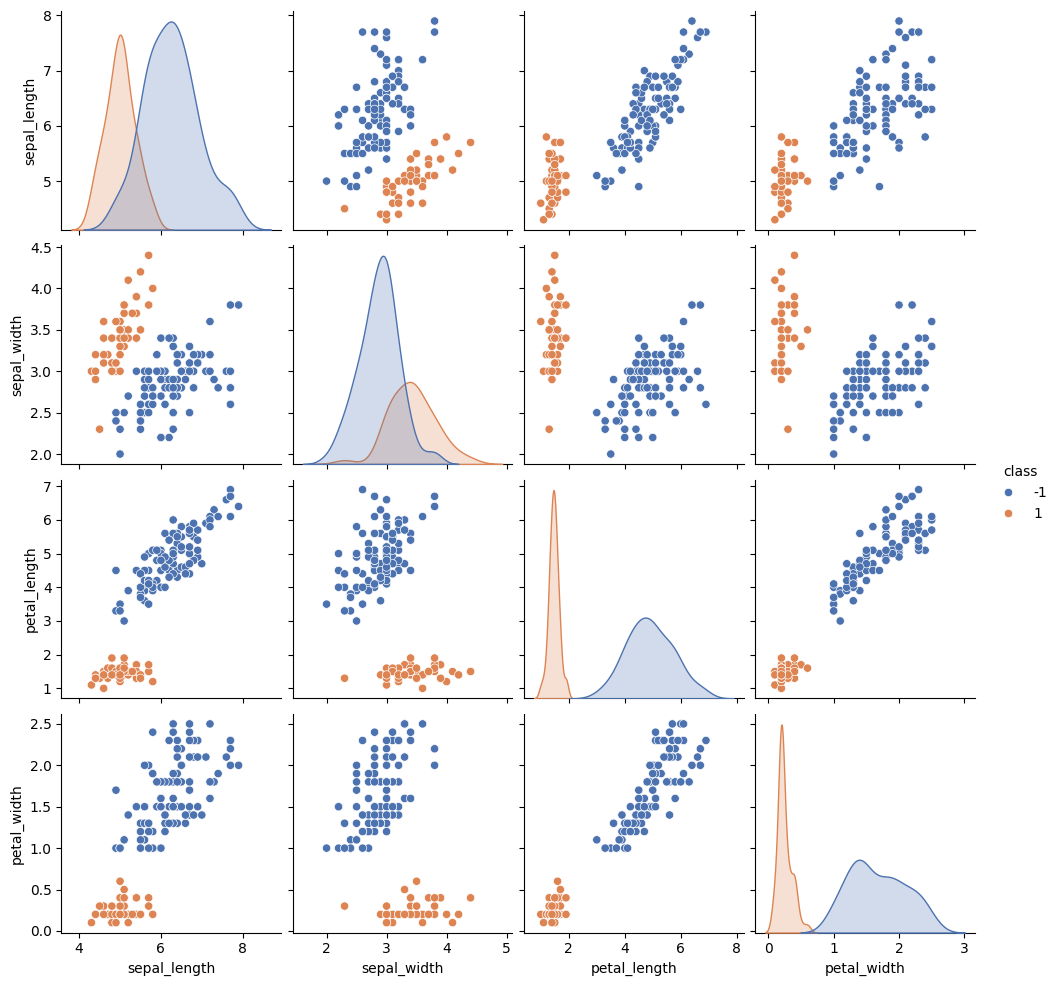

In [30]:
sns.pairplot(data=df, hue='class', palette='deep')

---

### **Hard margin stochastic gradient descent**

For 0 epoch
Loss: [0.46839632]
For 1 epoch
Loss: [0.45300109]
For 2 epoch
Loss: [0.44946917]
For 3 epoch
Loss: [0.44239199]
For 4 epoch
Loss: [0.4353144]
For 5 epoch
Loss: [0.4298423]
For 6 epoch
Loss: [0.4227635]
For 7 epoch
Loss: [0.41568428]
For 8 epoch
Loss: [0.40860466]
For 9 epoch
Loss: [0.40144582]
For 10 epoch
Loss: [0.39431108]
For 11 epoch
Loss: [0.38866361]
For 12 epoch
Loss: [0.38135073]
For 13 epoch
Loss: [0.37403757]
For 14 epoch
Loss: [0.36838884]
For 15 epoch
Loss: [0.3610747]
For 16 epoch
Loss: [0.35521597]
For 17 epoch
Loss: [0.34768707]
For 18 epoch
Loss: [0.34182748]
For 19 epoch
Loss: [0.33429773]
For 20 epoch
Loss: [0.32696156]
For 21 epoch
Loss: [0.32101552]
For 22 epoch
Loss: [0.31363364]
For 23 epoch
Loss: [0.3063696]
For 24 epoch
Loss: [0.30039964]
For 25 epoch
Loss: [0.29304007]
For 26 epoch
Loss: [0.28583631]
For 27 epoch
Loss: [0.27980446]
For 28 epoch
Loss: [0.27263118]
For 29 epoch
Loss: [0.26653528]
For 30 epoch
Loss: [0.26039795]
For 31 epoch
Loss: [0.2

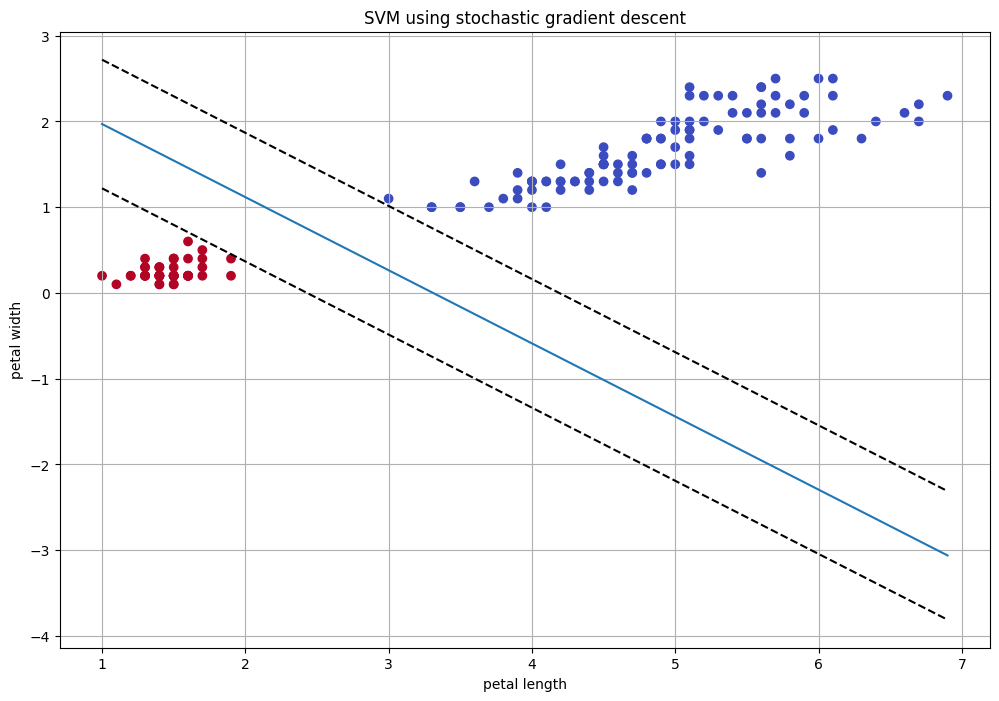

In [31]:
from hard_margin_sgd import Hard_margin_SGD

X = df[['petal_length', 'petal_width']].to_numpy()

y = df['class'].to_numpy()

hard_margin_sgd = Hard_margin_SGD()
hard_margin_sgd.fit(X, y, max_iters=1000, lr=0.001, stats=True)


plt.figure(figsize=(12, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, label='data', cmap='coolwarm')
plt.grid()
plt.xlabel('petal length')
plt.ylabel('petal width')
plt.title('SVM using stochastic gradient descent')

w1 = hard_margin_sgd.weights[0]
w2 = hard_margin_sgd.weights[1]
b = hard_margin_sgd.bias
a = -(w1 / w2)
intercept = -(b / w2)

x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x2 = (a * x1) + intercept
print(f'y = {a}x + {intercept}')

plt.plot(x1, x2)
plt.plot(x1, x2 + 0.75, '--', color='black')
plt.plot(x1, x2 - 0.75, '--', color='black')

---

### **Soft margin gradient descent**

For 0 epochs loss:
73.68318937419016
For 1 epochs loss:
79.11074247674358
For 2 epochs loss:
70.93193314283606
For 3 epochs loss:
80.89900610934573
For 4 epochs loss:
68.1811838139795
For 5 epochs loss:
82.68713721010471
For 6 epochs loss:
65.6466639842511
For 7 epochs loss:
78.82359770237616
For 8 epochs loss:
69.00847300817267
For 9 epochs loss:
80.61168883496232
For 10 epochs loss:
66.30349699068285
For 11 epochs loss:
79.77114087010025
For 12 epochs loss:
66.4778258111199
For 13 epochs loss:
80.23483501823576
For 14 epochs loss:
65.36161954862699
For 15 epochs loss:
78.53087086222078
For 16 epochs loss:
66.3753864778553
For 17 epochs loss:
78.5684244826779
For 18 epochs loss:
65.67305504148418
For 19 epochs loss:
77.72766262981926
For 20 epochs loss:
65.84230907198787
For 21 epochs loss:
76.88686225846182
For 22 epochs loss:
66.01708914903686
For 23 epochs loss:
76.92427378450265
For 24 epochs loss:
65.31646915469886
For 25 epochs loss:
75.65152934160372
For 26 epochs loss:
65.9236

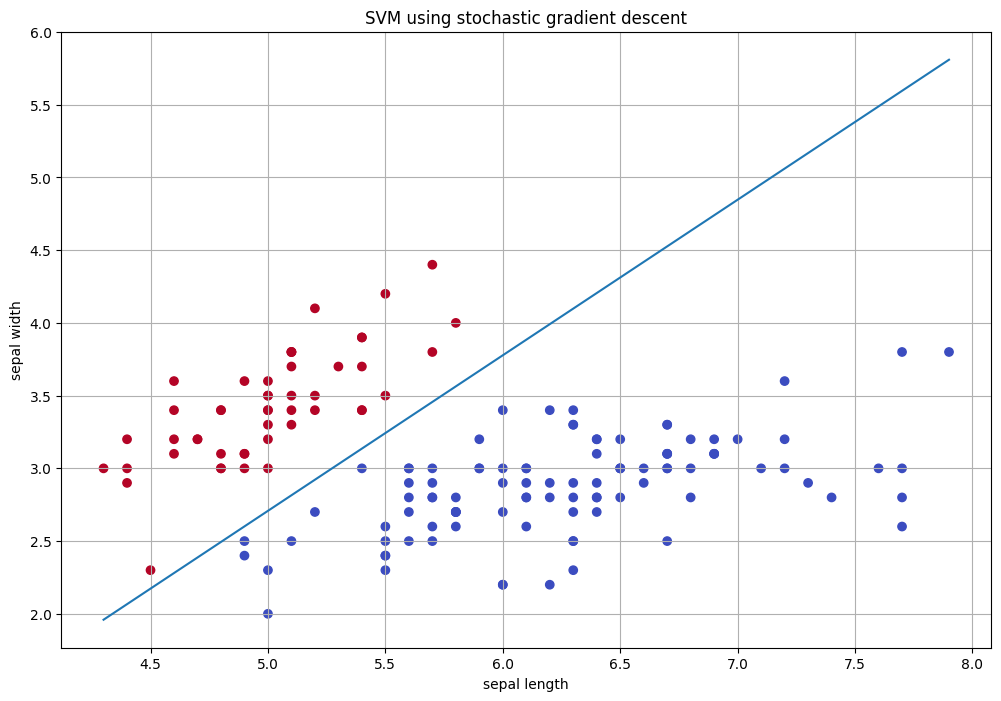

In [32]:
from soft_margin_gd import Soft_margin_GD
X = df[['sepal_length', 'sepal_width']].to_numpy()
y = df['class'].to_numpy()
soft_margin_gd = Soft_margin_GD()
soft_margin_gd.fit(X, y, max_iters=1000, lr=0.0001, stats=True, C=100)


plt.figure(figsize=(12, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, label='data', cmap='coolwarm')
plt.grid()
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.title('SVM using stochastic gradient descent')

w1 = soft_margin_gd.weights[0]
w2 = soft_margin_gd.weights[1]
b = soft_margin_gd.bias
a = -(w1 / w2)
intercept = -(b / w2)

x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x2 = (a * x1) + intercept
print(f'y = {a}x + {intercept}')

plt.plot(x1, x2)

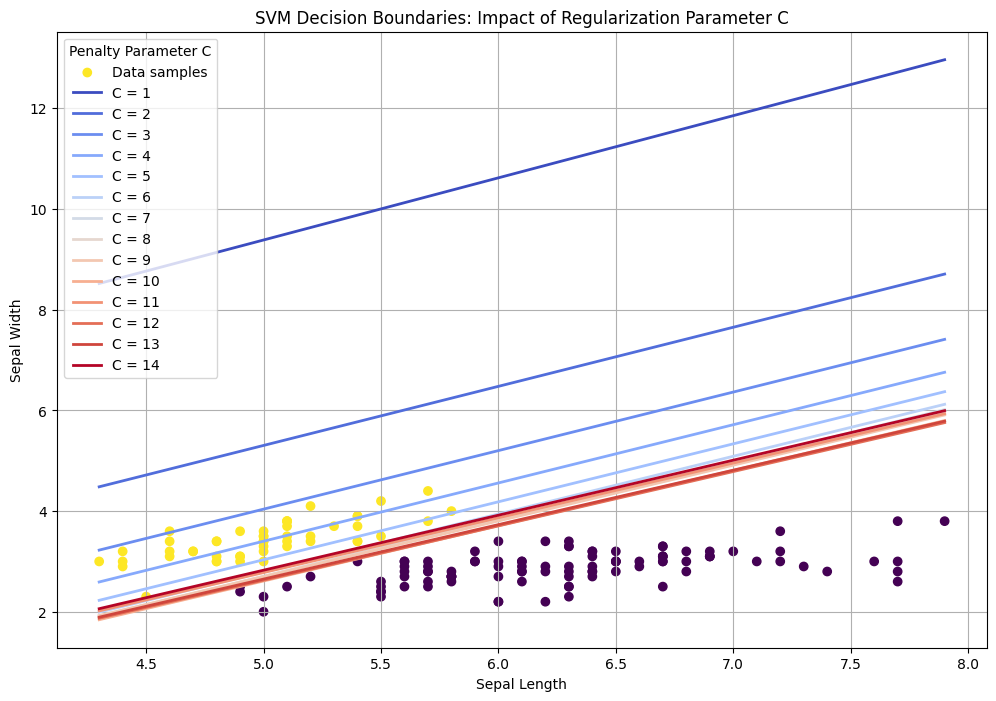

In [33]:
# === C test ===
X = df[['sepal_length', 'sepal_width']].to_numpy()
y = df['class'].to_numpy()


cs = [i for i in range(1, 15)]
c_test = Soft_margin_GD()

num_plots = len(cs)
colormap = plt.cm.coolwarm
colors = [colormap(i) for i in np.linspace(0, 1, num_plots)]

plt.figure(figsize=(12, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, label='Data samples')

loss_test = []

for idx, c in enumerate(cs):
    c_test.fit(X, y, max_iters=1000, lr=0.001, stats=False, C=c)

    w = c_test.weights.flatten()
    b = c_test.bias

    a_slope = -(w[0] / w[1])
    intercept = -(b / w[1])

    x_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
    y_vals = (a_slope * x_vals) + intercept
    
    plt.plot(x_vals, y_vals, label=f'C = {c}', color=colors[idx], linewidth=2)

    current_loss = hinge_loss(X, y, c_test.weights, c_test.bias) 
    loss_test.append(current_loss)

plt.title('SVM Decision Boundaries: Impact of Regularization Parameter C',)
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend(title="Penalty Parameter C")
plt.grid()


---

### **Soft margin stochastic gradient descent**

For 0 epochs loss:
0.8670567515475023
For 1 epochs loss:
0.8666382627583635
For 2 epochs loss:
0.8685924145654704
For 3 epochs loss:
0.9040659812580105
For 4 epochs loss:
1.8932573493458036
For 5 epochs loss:
0.7961461077963917
For 6 epochs loss:
1.5426938936892305
For 7 epochs loss:
0.799476426994485
For 8 epochs loss:
1.0727421600993008
For 9 epochs loss:
2.165184584720052
For 10 epochs loss:
0.7869431920264021
For 11 epochs loss:
0.8207073043376558
For 12 epochs loss:
0.8360199000157975
For 13 epochs loss:
0.9408342915365127
For 14 epochs loss:
0.9297519764858748
For 15 epochs loss:
1.3799356777282024
For 16 epochs loss:
0.7534472248898926
For 17 epochs loss:
0.6999876075961874
For 18 epochs loss:
0.7218977565723389
For 19 epochs loss:
1.1924963721542094
For 20 epochs loss:
0.7412883009738884
For 21 epochs loss:
0.8253920462435027
For 22 epochs loss:
0.8913431145772978
For 23 epochs loss:
0.8589357193113145
For 24 epochs loss:
0.7189520048851445
For 25 epochs loss:
0.816347521750614

(np.float64(0.5), np.float64(7.1), np.float64(4.0), np.float64(8.0))

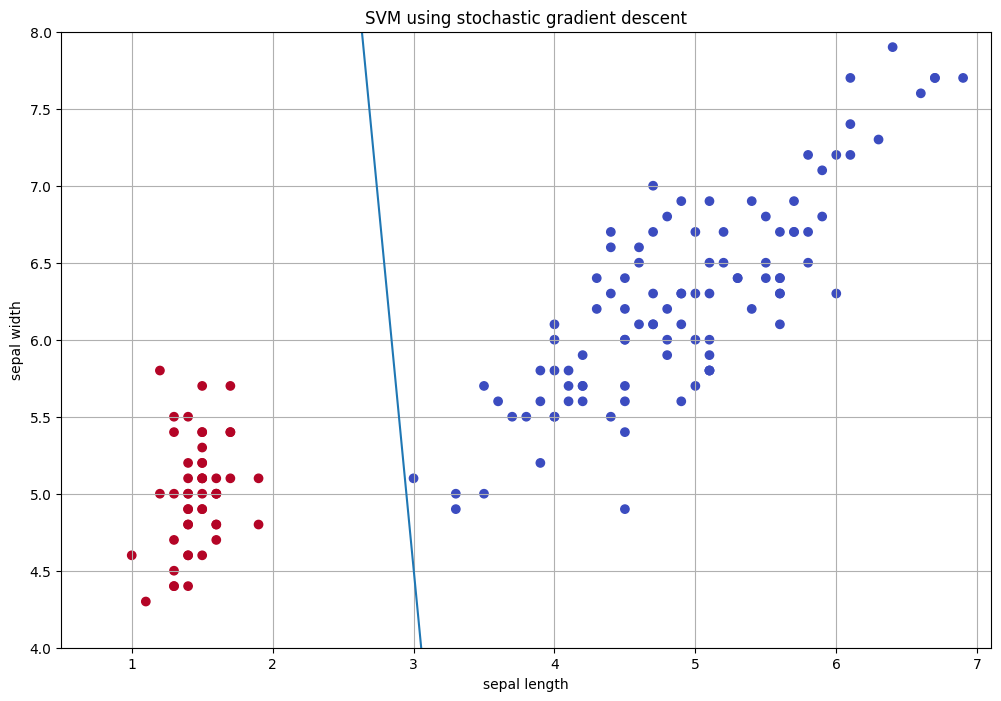

In [34]:
from soft_margin_sgd import Soft_margin_SGD
X = df[['petal_length', 'sepal_length']].to_numpy()
y = df['class'].to_numpy()
soft_margin_sgd = Soft_margin_SGD()
soft_margin_sgd.fit(X, y, max_iters=1000, lr=0.003, stats=True, C=8)


plt.figure(figsize=(12, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, label='data', cmap='coolwarm')
plt.grid()
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.title('SVM using stochastic gradient descent')

w1 = soft_margin_sgd.weights[0]
w2 = soft_margin_sgd.weights[1]
b = soft_margin_sgd.bias
a = -(w1 / w2)
intercept = -(b / w2)

x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x2 = (a * x1) + intercept
print(f'y = {a}x + {intercept}')

plt.plot(x1, x2)
plt.axis([0.5, 7.1, 4, 8])

---

### **Soft margin stochastic gradient descent**

For 0 epochs loss:
6.969730278241734
For 1 epochs loss:
5.711074229186245
For 2 epochs loss:
5.087996261535658
For 3 epochs loss:
4.9261954163260935
For 4 epochs loss:
4.845675333937833
For 5 epochs loss:
4.762024044135306
For 6 epochs loss:
4.627742572670398
For 7 epochs loss:
4.548391334544729
For 8 epochs loss:
4.457515657259831
For 9 epochs loss:
4.4282087350584405
For 10 epochs loss:
4.286196077930093
For 11 epochs loss:
4.204220705544541
For 12 epochs loss:
4.113909757227422
For 13 epochs loss:
4.038224144445305
For 14 epochs loss:
3.957636138448727
For 15 epochs loss:
3.8911103730262884
For 16 epochs loss:
3.805139240819996
For 17 epochs loss:
3.7336231174025563
For 18 epochs loss:
3.663188983628928
For 19 epochs loss:
3.6063124531939206
For 20 epochs loss:
3.5380832816078827
For 21 epochs loss:
3.4657091512224945
For 22 epochs loss:
3.3976968623584156
For 23 epochs loss:
3.3313813793692995
For 24 epochs loss:
3.265738364661833
For 25 epochs loss:
3.2051622342360795
For 26 epoch

(np.float64(0.0), np.float64(2.6), np.float64(1.8), np.float64(4.6))

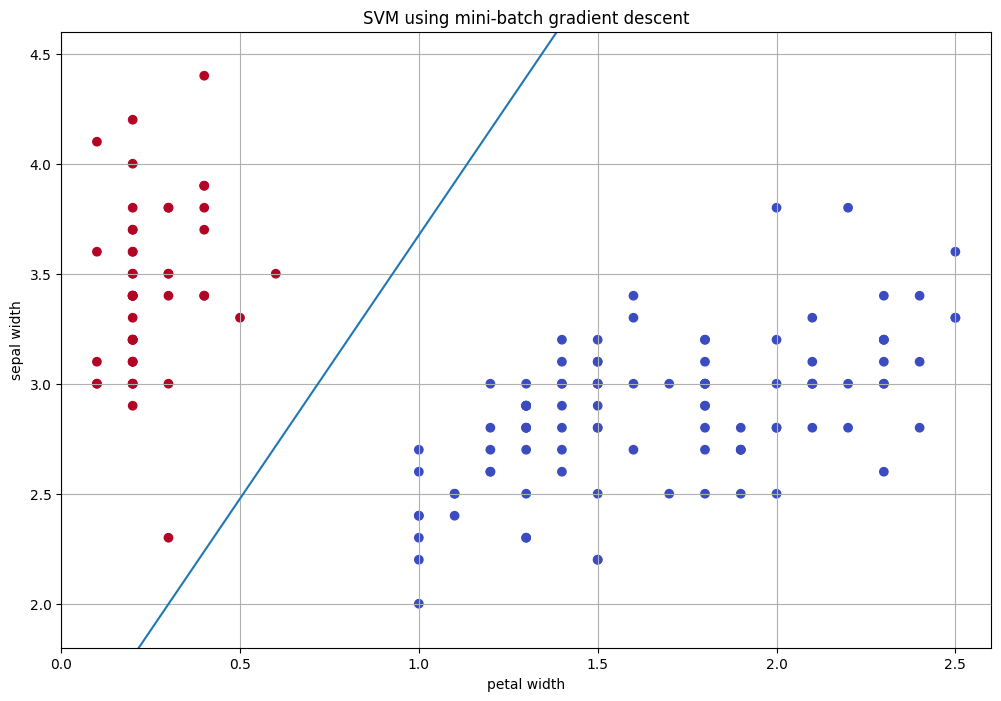

In [35]:
from soft_margin_mini import Soft_margin_MINI
X = df[['petal_width', 'sepal_width']].to_numpy()
y = df['class'].to_numpy()
soft_margin_mini = Soft_margin_MINI()
soft_margin_mini.fit(X, y, max_iters=1000, lr=0.001, stats=True, C=8)

plt.figure(figsize=(12, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, label='data', cmap='coolwarm')
plt.grid()
plt.xlabel('petal width')
plt.ylabel('sepal width')
plt.title('SVM using mini-batch gradient descent')

w1 = soft_margin_mini.weights[0]
w2 = soft_margin_mini.weights[1]
b = soft_margin_mini.bias
a = -(w1 / w2)
intercept = -(b / w2)

x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x2 = (a * x1) + intercept
print(f'y = {a}x + {intercept}')

plt.plot(x1, x2)
plt.axis([0, 2.6, 1.8, 4.6])

---

### **Kernel SVM (RBF)** 

In [ ]:
from kernel_svm_rbf import Kernel_svm_RBF

